# Week8 Ablation Study

按照论文中的消融实验思路，完成四组实验：

- 实验 A：原始输入 + `CNNRegressor(kernel_size=3)`
- 实验 B：原始输入 + `MultiSightCNN(kernel_sizes=(3,5,7))`
- 实验 C：`trend -> MLP`，`periodic -> CNNRegressor(kernel_size=3)`，最后相加
- 实验 D：`trend -> MLP`，`periodic -> MultiSightCNN(kernel_sizes=(3,5,7))`，最后相加

其中 A/B 为对照组，C/D 为实验组，用于验证二项分解模块的有效性。

In [1]:
import os
import sys
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week8' else _cwd
sys.path.insert(0, os.path.join(_root, 'week5'))
sys.path.insert(0, os.path.join(_root, 'week7'))
sys.path.insert(0, os.path.join(_root, 'week8'))

from data import Electricity
from models import CNNRegressor, MultiSightCNN
from ablation import make_ablation_datasets
from ablation_models import TrendPeriodicSingleSightModel, TrendPeriodicMultiSightModel

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 实验参数

为保持一致，继续使用 `168 = 24 x 7` 的历史窗口。

In [2]:
SEQ_LEN = 168
PRED_LEN = 1
HEIGHT = 24
WIDTH = 7
TREND_WINDOW = 25
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
RANDOM_SEED = 42
MAX_USERS = 20
MAX_SAMPLES = 1000

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert HEIGHT * WIDTH == SEQ_LEN

## 2. 读取 electricity 数据并构造滑窗样本

这里复用第五周的 `Electricity` 数据读取逻辑。

In [3]:
elec = Electricity(test_ratio=0.2, max_users=MAX_USERS, max_samples_per_user=MAX_SAMPLES)
X_train, y_train, X_test, y_test = elec.get_global_slided_dataset(
    d_num=SEQ_LEN,
    h_num=PRED_LEN,
    use_global_scaler=True,
)

print(f'Users: {elec.n_users}')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

if X_train.ndim != 2 or X_test.ndim != 2 or len(X_test) == 0:
    raise ValueError(
        '当前参数下没有构造出有效的训练/测试滑窗。'
        '请增大 MAX_SAMPLES，或减小 SEQ_LEN。'
    )

Users: 20
X_train shape: (12640, 168)
y_train shape: (12640, 1)
X_test shape: (640, 168)
y_test shape: (640, 1)


## 3. 构造四组实验所需输入

这里统一生成三类输入：

- 原始输入 `raw_*_2d`，给实验 A/B 使用；
- 趋势项 `trend_*_1d`，给实验 C/D 的 MLP 分支使用；
- 周期项 `periodic_*_2d`，给实验 C/D 的 CNN 分支使用。

In [4]:
datasets = make_ablation_datasets(
    x_train=X_train,
    y_train=y_train,
    x_test=X_test,
    y_test=y_test,
    height=HEIGHT,
    width=WIDTH,
    trend_window=TREND_WINDOW,
)

for key, value in datasets.items():
    print(f'{key}: {value.shape}')

raw_train_2d: (12640, 1, 24, 7)
raw_test_2d: (640, 1, 24, 7)
trend_train_1d: (12640, 168)
trend_test_1d: (640, 168)
periodic_train_2d: (12640, 1, 24, 7)
periodic_test_2d: (640, 1, 24, 7)
train_y: (12640, 1)
test_y: (640, 1)


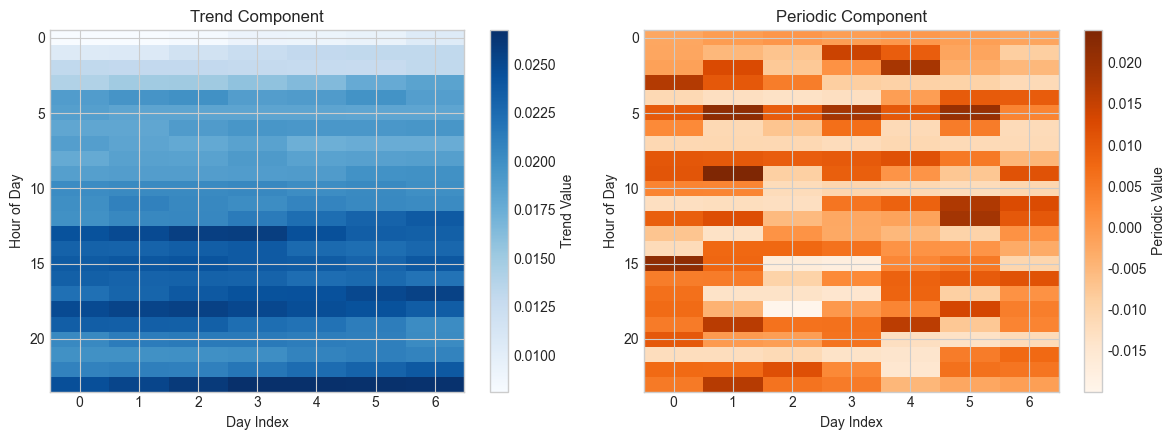

In [5]:
# 可视化趋势项与周期项，便于检查分解结果是否合理。
sample_trend = datasets['trend_train_1d'][0].reshape(HEIGHT, WIDTH)
sample_periodic = datasets['periodic_train_2d'][0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = axes[0].imshow(sample_trend, aspect='auto', cmap='Blues')
axes[0].set_title('Trend Component')
axes[0].set_xlabel('Day Index')
axes[0].set_ylabel('Hour of Day')
plt.colorbar(im0, ax=axes[0], label='Trend Value')

im1 = axes[1].imshow(sample_periodic, aspect='auto', cmap='Oranges')
axes[1].set_title('Periodic Component')
axes[1].set_xlabel('Day Index')
axes[1].set_ylabel('Hour of Day')
plt.colorbar(im1, ax=axes[1], label='Periodic Value')
plt.tight_layout()
plt.show()

## 4. 构建 DataLoader

A/B 组使用单输入 `TensorDataset(x, y)`；
C/D 组使用双输入 `TensorDataset(trend_x, periodic_x, y)`。

In [6]:
train_ds_a = TensorDataset(torch.from_numpy(datasets['raw_train_2d']), torch.from_numpy(datasets['train_y']))
test_ds_a = TensorDataset(torch.from_numpy(datasets['raw_test_2d']), torch.from_numpy(datasets['test_y']))

train_ds_b = TensorDataset(torch.from_numpy(datasets['raw_train_2d']), torch.from_numpy(datasets['train_y']))
test_ds_b = TensorDataset(torch.from_numpy(datasets['raw_test_2d']), torch.from_numpy(datasets['test_y']))

train_ds_c = TensorDataset(
    torch.from_numpy(datasets['trend_train_1d']),
    torch.from_numpy(datasets['periodic_train_2d']),
    torch.from_numpy(datasets['train_y']),
)
test_ds_c = TensorDataset(
    torch.from_numpy(datasets['trend_test_1d']),
    torch.from_numpy(datasets['periodic_test_2d']),
    torch.from_numpy(datasets['test_y']),
)

train_ds_d = TensorDataset(
    torch.from_numpy(datasets['trend_train_1d']),
    torch.from_numpy(datasets['periodic_train_2d']),
    torch.from_numpy(datasets['train_y']),
)
test_ds_d = TensorDataset(
    torch.from_numpy(datasets['trend_test_1d']),
    torch.from_numpy(datasets['periodic_test_2d']),
    torch.from_numpy(datasets['test_y']),
)

train_loader_a = DataLoader(train_ds_a, batch_size=BATCH_SIZE, shuffle=True)
test_loader_a = DataLoader(test_ds_a, batch_size=BATCH_SIZE, shuffle=False)
train_loader_b = DataLoader(train_ds_b, batch_size=BATCH_SIZE, shuffle=True)
test_loader_b = DataLoader(test_ds_b, batch_size=BATCH_SIZE, shuffle=False)
train_loader_c = DataLoader(train_ds_c, batch_size=BATCH_SIZE, shuffle=True)
test_loader_c = DataLoader(test_ds_c, batch_size=BATCH_SIZE, shuffle=False)
train_loader_d = DataLoader(train_ds_d, batch_size=BATCH_SIZE, shuffle=True)
test_loader_d = DataLoader(test_ds_d, batch_size=BATCH_SIZE, shuffle=False)

print(f'Experiment A train samples: {len(train_ds_a)}')
print(f'Experiment B train samples: {len(train_ds_b)}')
print(f'Experiment C train samples: {len(train_ds_c)}')
print(f'Experiment D train samples: {len(train_ds_d)}')

Experiment A train samples: 12640
Experiment B train samples: 12640
Experiment C train samples: 12640
Experiment D train samples: 12640


## 5. 统一训练与评估函数

为了支持单输入模型和双输入融合模型，这里把训练函数写成兼容两种 batch 结构的形式。

In [7]:
def unpack_batch(batch, device):
    """根据 batch 长度判断是单输入还是双输入。"""
    if len(batch) == 2:
        x_b, y_b = batch
        return (x_b.to(device),), y_b.to(device)
    if len(batch) == 3:
        trend_x, periodic_x, y_b = batch
        return (trend_x.to(device), periodic_x.to(device)), y_b.to(device)
    raise ValueError(f'不支持的 batch 长度: {len(batch)}')


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for batch in data_loader:
            model_inputs, y_b = unpack_batch(batch, device)
            y_hat = model(*model_inputs)
            loss = criterion(y_hat, y_b)
            total_loss += loss.item() * y_b.size(0)
            preds.append(y_hat.cpu().numpy())
            targets.append(y_b.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(mse)
    avg_loss = total_loss / len(data_loader.dataset)
    return avg_loss, mae, rmse


def train_model(model, train_loader, test_loader, epochs, lr, device, experiment_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_mae': [],
        'test_rmse': [],
    }
    best_state = deepcopy(model.state_dict())
    best_rmse = float('inf')

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            model_inputs, y_b = unpack_batch(batch, device)
            optimizer.zero_grad()
            y_hat = model(*model_inputs)
            loss = criterion(y_hat, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y_b.size(0)

        train_loss = total_loss / len(train_loader.dataset)
        test_loss, test_mae, test_rmse = evaluate_model(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_mae'].append(test_mae)
        history['test_rmse'].append(test_rmse)

        if test_rmse < best_rmse:
            best_rmse = test_rmse
            best_state = deepcopy(model.state_dict())

        print(
            f'[{experiment_name}] Epoch {epoch + 1:02d}/{epochs} | '
            f'train_loss={train_loss:.5f} | '
            f'test_loss={test_loss:.5f} | '
            f'test_mae={test_mae:.5f} | '
            f'test_rmse={test_rmse:.5f}'
        )

    model.load_state_dict(best_state)
    return model, history

## 6. 四组实验

这里依次训练 A/B/C/D 四组模型。

In [8]:
print('===== Experiment A: Raw Input + CNNRegressor(kernel_size=3) =====')
model_a = CNNRegressor(
    in_channels=1,
    hidden_channels=16,
    kernel_size=3,
    output_dim=PRED_LEN,
).to(device)
model_a, history_a = train_model(
    model=model_a,
    train_loader=train_loader_a,
    test_loader=test_loader_a,
    epochs=EPOCHS,
    lr=LR,
    device=device,
    experiment_name='A',
)

===== Experiment A: Raw Input + CNNRegressor(kernel_size=3) =====
[A] Epoch 01/10 | train_loss=0.00891 | test_loss=0.00469 | test_mae=0.04143 | test_rmse=0.06851
[A] Epoch 02/10 | train_loss=0.00513 | test_loss=0.00512 | test_mae=0.04137 | test_rmse=0.07155
[A] Epoch 03/10 | train_loss=0.00493 | test_loss=0.00441 | test_mae=0.03938 | test_rmse=0.06644
[A] Epoch 04/10 | train_loss=0.00472 | test_loss=0.00424 | test_mae=0.03935 | test_rmse=0.06515
[A] Epoch 05/10 | train_loss=0.00444 | test_loss=0.00388 | test_mae=0.03781 | test_rmse=0.06227
[A] Epoch 06/10 | train_loss=0.00404 | test_loss=0.00369 | test_mae=0.04065 | test_rmse=0.06078
[A] Epoch 07/10 | train_loss=0.00352 | test_loss=0.00311 | test_mae=0.03389 | test_rmse=0.05579
[A] Epoch 08/10 | train_loss=0.00295 | test_loss=0.00228 | test_mae=0.03048 | test_rmse=0.04771
[A] Epoch 09/10 | train_loss=0.00244 | test_loss=0.00191 | test_mae=0.02772 | test_rmse=0.04371
[A] Epoch 10/10 | train_loss=0.00208 | test_loss=0.00148 | test_mae=0.

In [9]:
print('===== Experiment B: Raw Input + MultiSightCNN(kernel_sizes=(3,5,7)) =====')
model_b = MultiSightCNN(
    in_channels=1,
    hidden_channels=16,
    kernel_sizes=(3, 5, 7),
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)
model_b, history_b = train_model(
    model=model_b,
    train_loader=train_loader_b,
    test_loader=test_loader_b,
    epochs=EPOCHS,
    lr=LR,
    device=device,
    experiment_name='B',
)

===== Experiment B: Raw Input + MultiSightCNN(kernel_sizes=(3,5,7)) =====
[B] Epoch 01/10 | train_loss=0.00681 | test_loss=0.00535 | test_mae=0.04214 | test_rmse=0.07317
[B] Epoch 02/10 | train_loss=0.00444 | test_loss=0.00223 | test_mae=0.02987 | test_rmse=0.04719
[B] Epoch 03/10 | train_loss=0.00176 | test_loss=0.00156 | test_mae=0.02377 | test_rmse=0.03950
[B] Epoch 04/10 | train_loss=0.00125 | test_loss=0.00105 | test_mae=0.01983 | test_rmse=0.03247
[B] Epoch 05/10 | train_loss=0.00117 | test_loss=0.00108 | test_mae=0.01981 | test_rmse=0.03284
[B] Epoch 06/10 | train_loss=0.00109 | test_loss=0.00090 | test_mae=0.01815 | test_rmse=0.02994
[B] Epoch 07/10 | train_loss=0.00102 | test_loss=0.00090 | test_mae=0.01824 | test_rmse=0.03001
[B] Epoch 08/10 | train_loss=0.00100 | test_loss=0.00088 | test_mae=0.01863 | test_rmse=0.02966
[B] Epoch 09/10 | train_loss=0.00092 | test_loss=0.00071 | test_mae=0.01736 | test_rmse=0.02671
[B] Epoch 10/10 | train_loss=0.00089 | test_loss=0.00074 | tes

In [10]:
print('===== Experiment C: Trend-MLP + Periodic-CNNRegressor =====')
model_c = TrendPeriodicSingleSightModel(
    trend_input_dim=SEQ_LEN,
    trend_hidden_dims=(64, 32),
    periodic_kernel_size=3,
    periodic_hidden_channels=16,
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)
model_c, history_c = train_model(
    model=model_c,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    epochs=EPOCHS,
    lr=LR,
    device=device,
    experiment_name='C',
)

===== Experiment C: Trend-MLP + Periodic-CNNRegressor =====
[C] Epoch 01/10 | train_loss=0.00550 | test_loss=0.00269 | test_mae=0.03031 | test_rmse=0.05191
[C] Epoch 02/10 | train_loss=0.00228 | test_loss=0.00086 | test_mae=0.01828 | test_rmse=0.02933
[C] Epoch 03/10 | train_loss=0.00126 | test_loss=0.00075 | test_mae=0.01688 | test_rmse=0.02735
[C] Epoch 04/10 | train_loss=0.00108 | test_loss=0.00093 | test_mae=0.01926 | test_rmse=0.03057
[C] Epoch 05/10 | train_loss=0.00096 | test_loss=0.00070 | test_mae=0.01645 | test_rmse=0.02642
[C] Epoch 06/10 | train_loss=0.00096 | test_loss=0.00074 | test_mae=0.01765 | test_rmse=0.02719
[C] Epoch 07/10 | train_loss=0.00092 | test_loss=0.00076 | test_mae=0.01817 | test_rmse=0.02759
[C] Epoch 08/10 | train_loss=0.00089 | test_loss=0.00080 | test_mae=0.01693 | test_rmse=0.02836
[C] Epoch 09/10 | train_loss=0.00084 | test_loss=0.00083 | test_mae=0.01960 | test_rmse=0.02888
[C] Epoch 10/10 | train_loss=0.00084 | test_loss=0.00087 | test_mae=0.01765 

In [11]:
print('===== Experiment D: Trend-MLP + Periodic-MultiSightCNN =====')
model_d = TrendPeriodicMultiSightModel(
    trend_input_dim=SEQ_LEN,
    trend_hidden_dims=(64, 32),
    periodic_kernel_sizes=(3, 5, 7),
    periodic_hidden_channels=16,
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)
model_d, history_d = train_model(
    model=model_d,
    train_loader=train_loader_d,
    test_loader=test_loader_d,
    epochs=EPOCHS,
    lr=LR,
    device=device,
    experiment_name='D',
)

===== Experiment D: Trend-MLP + Periodic-MultiSightCNN =====
[D] Epoch 01/10 | train_loss=0.00623 | test_loss=0.00304 | test_mae=0.03194 | test_rmse=0.05517
[D] Epoch 02/10 | train_loss=0.00295 | test_loss=0.00205 | test_mae=0.02827 | test_rmse=0.04525
[D] Epoch 03/10 | train_loss=0.00168 | test_loss=0.00101 | test_mae=0.01956 | test_rmse=0.03173
[D] Epoch 04/10 | train_loss=0.00122 | test_loss=0.00084 | test_mae=0.01804 | test_rmse=0.02905
[D] Epoch 05/10 | train_loss=0.00115 | test_loss=0.00067 | test_mae=0.01578 | test_rmse=0.02587
[D] Epoch 06/10 | train_loss=0.00089 | test_loss=0.00068 | test_mae=0.01609 | test_rmse=0.02612
[D] Epoch 07/10 | train_loss=0.00087 | test_loss=0.00095 | test_mae=0.02004 | test_rmse=0.03082
[D] Epoch 08/10 | train_loss=0.00082 | test_loss=0.00063 | test_mae=0.01508 | test_rmse=0.02504
[D] Epoch 09/10 | train_loss=0.00078 | test_loss=0.00063 | test_mae=0.01554 | test_rmse=0.02513
[D] Epoch 10/10 | train_loss=0.00080 | test_loss=0.00065 | test_mae=0.01494

## 7. 消融实验结果对比

这里比较四组实验的测试集 RMSE 曲线与最佳指标。

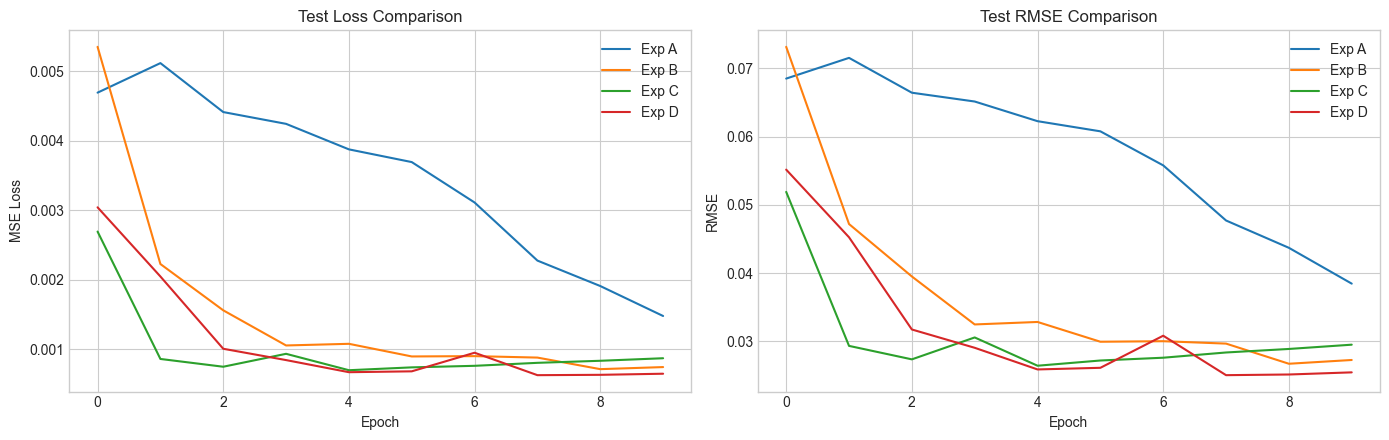

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(history_a['test_loss'], label='Exp A')
axes[0].plot(history_b['test_loss'], label='Exp B')
axes[0].plot(history_c['test_loss'], label='Exp C')
axes[0].plot(history_d['test_loss'], label='Exp D')
axes[0].set_title('Test Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history_a['test_rmse'], label='Exp A')
axes[1].plot(history_b['test_rmse'], label='Exp B')
axes[1].plot(history_c['test_rmse'], label='Exp C')
axes[1].plot(history_d['test_rmse'], label='Exp D')
axes[1].set_title('Test RMSE Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
summary_df = pd.DataFrame([
    {'experiment': 'A', 'model': 'Raw + CNNRegressor(k=3)', 'best_test_mae': min(history_a['test_mae']), 'best_test_rmse': min(history_a['test_rmse']), 'best_test_loss': min(history_a['test_loss'])},
    {'experiment': 'B', 'model': 'Raw + MultiSightCNN(3,5,7)', 'best_test_mae': min(history_b['test_mae']), 'best_test_rmse': min(history_b['test_rmse']), 'best_test_loss': min(history_b['test_loss'])},
    {'experiment': 'C', 'model': 'Trend-MLP + Periodic-CNNRegressor(k=3)', 'best_test_mae': min(history_c['test_mae']), 'best_test_rmse': min(history_c['test_rmse']), 'best_test_loss': min(history_c['test_loss'])},
    {'experiment': 'D', 'model': 'Trend-MLP + Periodic-MultiSightCNN(3,5,7)', 'best_test_mae': min(history_d['test_mae']), 'best_test_rmse': min(history_d['test_rmse']), 'best_test_loss': min(history_d['test_loss'])},
]).sort_values(by='best_test_rmse').reset_index(drop=True)
summary_df

,experiment,model,best_test_mae,best_test_rmse,best_test_loss
0,D,"Trend-MLP + Periodic-MultiSightCNN(3,5,7)",0.014939,0.025036,0.000627
1,C,Trend-MLP + Periodic-CNNRegressor(k=3),0.016446,0.026420,0.000698
2,B,"Raw + MultiSightCNN(3,5,7)",0.016610,0.026710,0.000713
3,A,Raw + CNNRegressor(k=3),0.024759,0.038454,0.001479


In [14]:
improve_c_vs_a = (min(history_a['test_rmse']) - min(history_c['test_rmse'])) / min(history_a['test_rmse']) * 100
improve_d_vs_b = (min(history_b['test_rmse']) - min(history_d['test_rmse'])) / min(history_b['test_rmse']) * 100

print(f'Experiment C vs A RMSE improvement: {improve_c_vs_a:.2f}%')
print(f'Experiment D vs B RMSE improvement: {improve_d_vs_b:.2f}%')

Experiment C vs A RMSE improvement: 31.29%
Experiment D vs B RMSE improvement: 6.27%


## 8. 检查点说明

实验 C 优于实验 A，说明在单视角 CNN 条件下，引入 `trend -> MLP` 与 `periodic -> CNN` 的二项分解是有效的。

实验 D 优于实验 B，说明在多视角 CNN 条件下，分解模块依然有效，并且与 Multi-sight 特征提取具有互补性。